# Pair Traiding 


## Step 2: Cointegration Testing via Augmented Dickey-Fuller (ADF)

After filtering the universe via Mutual Information, we test for cointegration using the ADF test. Two series are cointegrated if their spread is stationary, meaning they maintain a long-term equilibrium relationship despite short-term deviations.

In [11]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
from io import StringIO
from pathlib import Path

# CSV_FILENAME = "sp500_data_2015-01-12_to_2026-01-02.csv"
# CSV_PATH = Path(__file__).resolve().parent / CSV_FILENAME

def load_tickers_from_file(file_path: str) -> list:
    """
    Loads tickers from a text file, one ticker per line.
    """
    with open(file_path, 'r') as f:
        tickers = [line.strip() for line in f if line.strip()]
    return tickers

def get_price_data(tickers: list, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Downloads adjusted close prices for given tickers.
    """
    print(f"Downloading price data for {len(tickers)} tickers...")
    
    raw = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=True,
        threads=True,
    )
    
    if raw.empty:
        raise ValueError("No data downloaded.")
    
    # Extract Adj Close prices
    if isinstance(raw.columns, pd.MultiIndex):
        if 'Adj Close' in raw.columns.get_level_values(0):
            prices = raw['Adj Close']
        else:
            raise ValueError("'Adj Close' not found in data.")
    else:
        prices = raw
    
    # Clean data: remove tickers with insufficient data
    min_observations = 100
    valid_tickers = [col for col in prices.columns if prices[col].notna().sum() > min_observations]
    prices = prices[valid_tickers].dropna(axis=1, how='all')
    
    print(f"Valid tickers after cleaning: {len(prices.columns)}")
    return prices

def test_cointegration(y: pd.Series, x: pd.Series) -> tuple:
    """
    Tests for cointegration between two price series using the Engle-Granger approach.
    
    Steps:
    1. Run OLS regression: y = α + β*x
    2. Calculate residuals (spread): ε = y - (α + β*x)
    3. Test residuals for stationarity using ADF test
    
    Returns:
    - adf_stat: ADF test statistic (more negative = stronger cointegration)
    - p_value: p-value of the ADF test
    - beta: hedge ratio from OLS regression
    """
    # Remove NaN values
    valid_idx = ~(y.isna() | x.isna())
    y_clean = y[valid_idx].values.reshape(-1, 1)
    x_clean = x[valid_idx].values.reshape(-1, 1)
    
    # Run OLS regression
    model = LinearRegression()
    model.fit(x_clean, y_clean)
    beta = model.coef_[0][0]
    
    # Calculate residuals (spread)
    spread = y_clean.flatten() - (model.predict(x_clean).flatten())
    
    # Run ADF test on the spread
    adf_result = adfuller(spread, maxlag=1, regression='c', autolag=None)
    adf_stat = adf_result[0]
    p_value = adf_result[1]
    
    return adf_stat, p_value, beta

def find_cointegrated_pairs(prices: pd.DataFrame, max_pairs: int = 50) -> pd.DataFrame:
    """
    Tests all possible pairs for cointegration and returns the top N most cointegrated pairs.
    
    Args:
        prices: DataFrame of price series
        max_pairs: Number of top pairs to return
    
    Returns:
        DataFrame with columns: ticker1, ticker2, adf_stat, p_value, beta
    """
    tickers = prices.columns.tolist()
    n_tickers = len(tickers)
    n_pairs = n_tickers * (n_tickers - 1) // 2
    
    print(f"\nTesting {n_pairs} pairs for cointegration...")
    print("This may take several minutes...\n")
    
    results = []
    
    for i, (ticker1, ticker2) in enumerate(combinations(tickers, 2)):
        if (i + 1) % 1000 == 0:
            print(f"Progress: {i+1}/{n_pairs} pairs tested ({100*(i+1)/n_pairs:.1f}%)")
        
        try:
            # Test both directions and take the best
            adf1, pval1, beta1 = test_cointegration(prices[ticker1], prices[ticker2])
            adf2, pval2, beta2 = test_cointegration(prices[ticker2], prices[ticker1])
            
            # Use the direction with stronger cointegration (more negative ADF)
            if adf1 < adf2:
                results.append({
                    'ticker1': ticker1,
                    'ticker2': ticker2,
                    'adf_stat': adf1,
                    'p_value': pval1,
                    'beta': beta1
                })
            else:
                results.append({
                    'ticker1': ticker2,
                    'ticker2': ticker1,
                    'adf_stat': adf2,
                    'p_value': pval2,
                    'beta': beta2
                })
        except Exception as e:
            # Skip pairs that cause errors
            continue
    
    print(f"\nTesting complete. {len(results)} valid pairs found.")
    
    # Convert to DataFrame and sort by ADF statistic (most negative = most cointegrated)
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('adf_stat', ascending=True).reset_index(drop=True)
    
    # Return top N pairs
    return results_df.head(max_pairs)

def load_data_as_downloaded(csv_path: str) -> pd.DataFrame:
    """Load a yfinance-style CSV and keep its two-level column layout."""
    data = pd.read_csv(csv_path, header=[0, 1], skiprows=[2])

    # First column is the date index in this exported format.
    date_col = data.columns[0]
    data[date_col] = pd.to_datetime(data[date_col], errors='coerce')
    data = data.dropna(subset=[date_col]).set_index(date_col)
    data.index.name = "Date"

    for col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    data.sort_index(inplace=True)
    return data

# ========== MAIN EXECUTION ==========

# Load tickers from file
ticker_file = r"G:\Mi unidad\2026\Tesis\Códigos\Data\tickers\sp500_tickers_All.txt"
tickers = load_tickers_from_file(ticker_file)
print(f"Loaded {len(tickers)} tickers from file")

#Tickers MI Log Price
tickers = ['RSG', 'WM', 'MA', 'V', 'CDNS', 'SNPS', 'AJG', 'BRO', 'AJG', 'MRSH', 'AJG', 'RSG', 'MCO', 'SPGI', 'AJG', 'CTAS', 'MSFT', 'NVDA', 'CTAS', 'RSG', 'BRO', 'MRSH', 'AJG', 'PGR', 'AJG', 'AON', 'CTAS', 'MSI', 'BRO', 'RSG', 'BRO', 'CTAS', 'KLAC', 'LRCX', 'AJG', 'MSI', 'CDNS', 'MSFT', 'MSI', 'RSG', 'AMAT', 'LRCX', 'AJG', 'WM', 'CTAS', 'PGR', 'CPRT', 'CTAS', 'CTAS', 'MSFT', 'AJG', 'MSFT', 'CTAS', 'FICO', 'CTAS', 'WM', 'MSFT', 'SNPS', 'AVGO', 'NVDA', 'CPRT', 'MSFT', 'MSI', 'WM', 'CTAS', 'MRSH', 'MRSH', 'RSG', 'AJG', 'TT', 'INTU', 'MSFT', 'PGR', 'RSG', 'AZO', 'ORLY', 'AJG', 'FICO', 'AJG', 'CPRT', 'CTAS', 'SNPS', 'GOOG', 'MSFT', 'MSFT', 'RSG', 'AMAT', 'KLAC', 'MSFT', 'MSI', 'BRO', 'MSFT', 'CDNS', 'CTAS', 'AVGO', 'KLAC', 'AON', 'MRSH', 'ETN', 'PH']

# Download price data (use prices, not returns, for cointegration testing)
# downloaded_data = load_data_as_downloaded(CSV_PATH)
# prices = downloaded_data.xs('Close', axis=1, level=0)
prices = get_price_data(tickers, start_date='2020-01-01', end_date='2026-03-01')

# Find top 50 cointegrated pairs
top_50_cointegrated = find_cointegrated_pairs(prices, max_pairs=50)

# Display results
print("\n" + "="*80)
print("TOP 50 MOST COINTEGRATED PAIRS (Engle-Granger ADF Test)")
print("="*80)
print(f"{'Rank':<6}{'Ticker 1':<10}{'Ticker 2':<10}{'ADF Stat':<12}{'P-Value':<12}{'Beta':<10}")
print("-"*80)

for idx, row in top_50_cointegrated.iterrows():
    sig = "***" if row['p_value'] < 0.01 else ("**" if row['p_value'] < 0.05 else ("*" if row['p_value'] < 0.10 else ""))
    print(f"{idx+1:<6}{row['ticker1']:<10}{row['ticker2']:<10}{row['adf_stat']:<12.4f}{row['p_value']:<12.4f}{row['beta']:<10.4f} {sig}")

print("\n*** p < 0.01, ** p < 0.05, * p < 0.10")
print("\nNote: More negative ADF statistic indicates stronger cointegration")
print("Critical values: 1%: -3.43, 5%: -2.86, 10%: -2.57")

# Save results to CSV
output_file = r"G:\Mi unidad\2026\Tesis\Códigos\Data\top_50_cointegrated_pairs.csv"
top_50_cointegrated.to_csv(output_file, index=False)
print(f"\nResults saved to: {output_file}")

Loaded 500 tickers from file


[*********************100%***********************]  30 of 30 completed


Valid tickers after cleaning: 30

Testing 435 pairs for cointegration...
This may take several minutes...


Testing complete. 435 valid pairs found.

TOP 50 MOST COINTEGRATED PAIRS (Engle-Granger ADF Test)
Rank  Ticker 1  Ticker 2  ADF Stat    P-Value     Beta      
--------------------------------------------------------------------------------
1     MA        TT        -4.5295     0.0002      0.8016     ***
2     MA        NVDA      -4.2155     0.0006      1.4776     ***
3     MA        V         -4.2067     0.0006      1.6576     ***
4     SNPS      MRSH      -4.1890     0.0007      2.9619     ***
5     MA        ETN       -4.0784     0.0011      0.9184     ***
6     MA        ORLY      -4.0046     0.0014      3.7736     ***
7     CDNS      ORLY      -3.9800     0.0015      3.3178     ***
8     MCO       TT        -3.9373     0.0018      0.7373     ***
9     MA        CTAS      -3.9287     0.0018      1.7464     ***
10    CDNS      AZO       -3.8793     0.0022      0.0844     ***
11


Pair #1: MA - TT
ADF Statistic: -4.5295 (p-value: 0.0002)


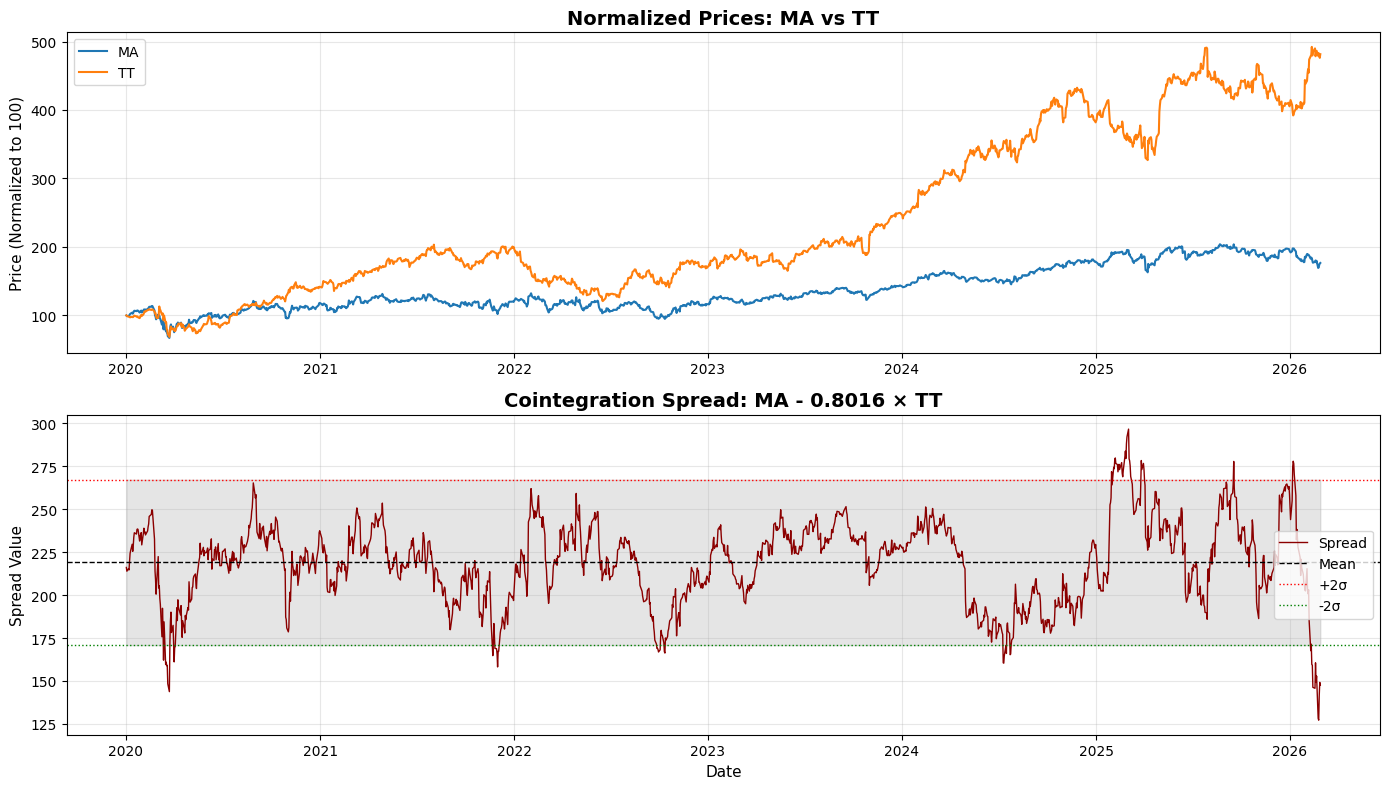


Spread Statistics for MA - TT:
Mean: 219.0544
Std Dev: 24.1027
Half-life (mean reversion): ~22.9 days

Pair #2: MA - NVDA
ADF Statistic: -4.2155 (p-value: 0.0006)


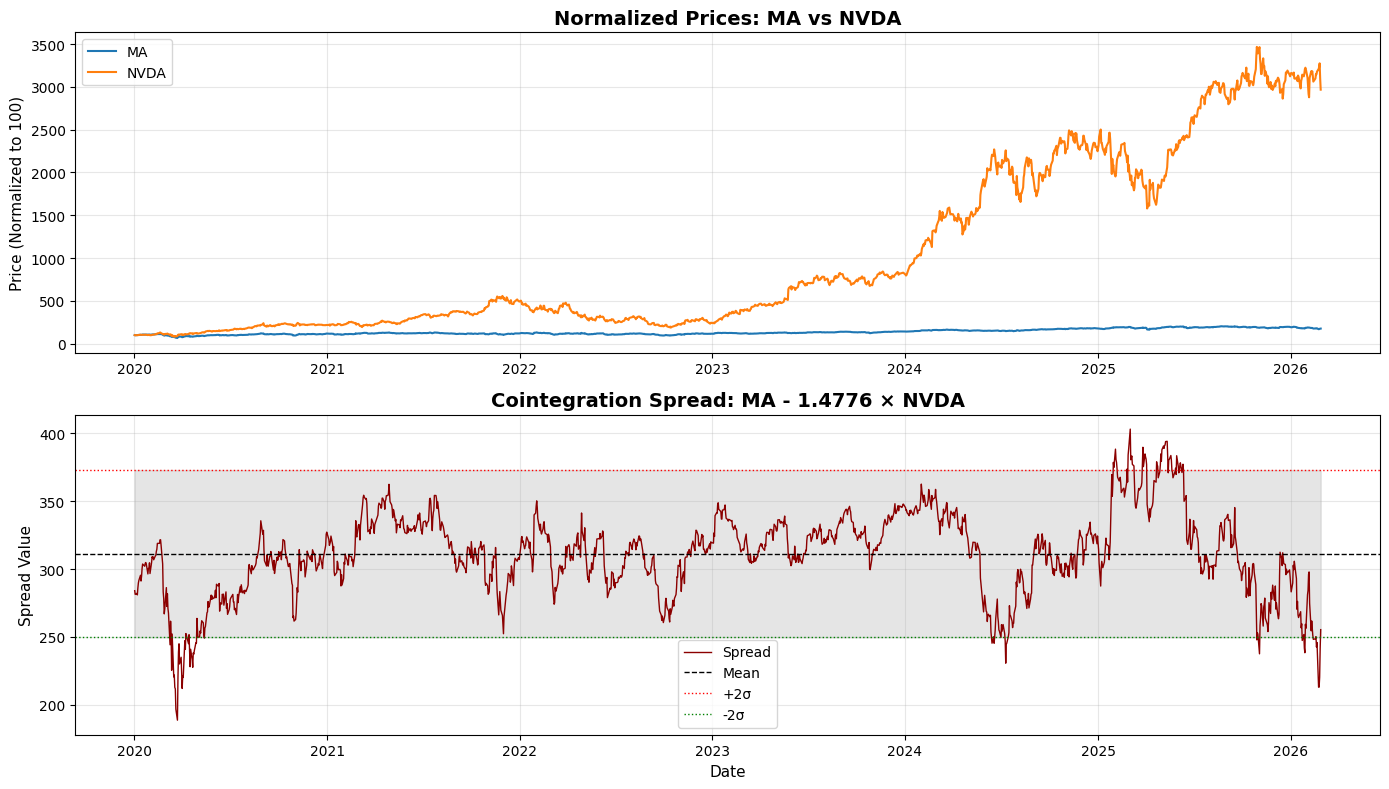


Spread Statistics for MA - NVDA:
Mean: 311.3179
Std Dev: 30.8273
Half-life (mean reversion): ~27.6 days

Pair #3: MA - V
ADF Statistic: -4.2067 (p-value: 0.0006)


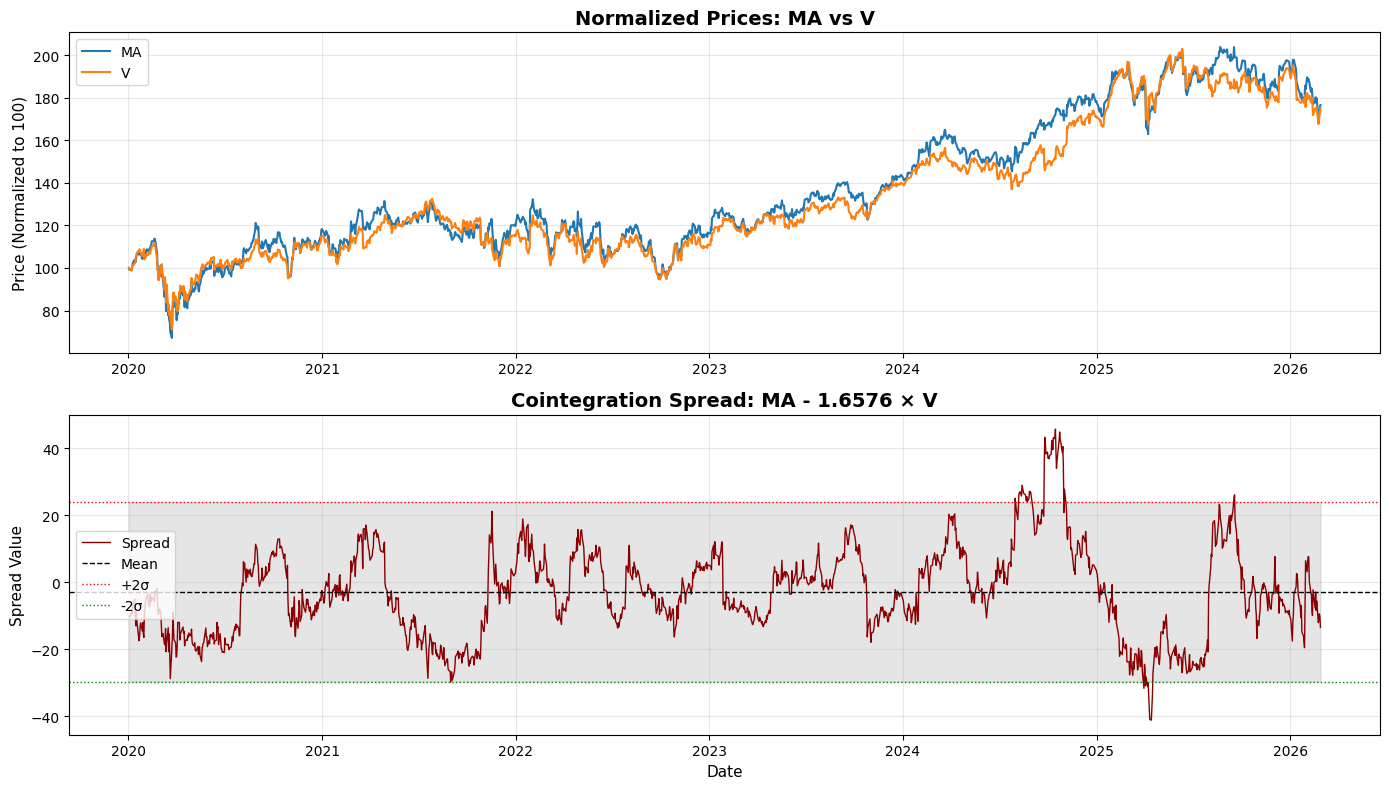


Spread Statistics for MA - V:
Mean: -2.8403
Std Dev: 13.3902
Half-life (mean reversion): ~27.8 days

Pair #4: SNPS - MRSH
ADF Statistic: -4.1890 (p-value: 0.0007)


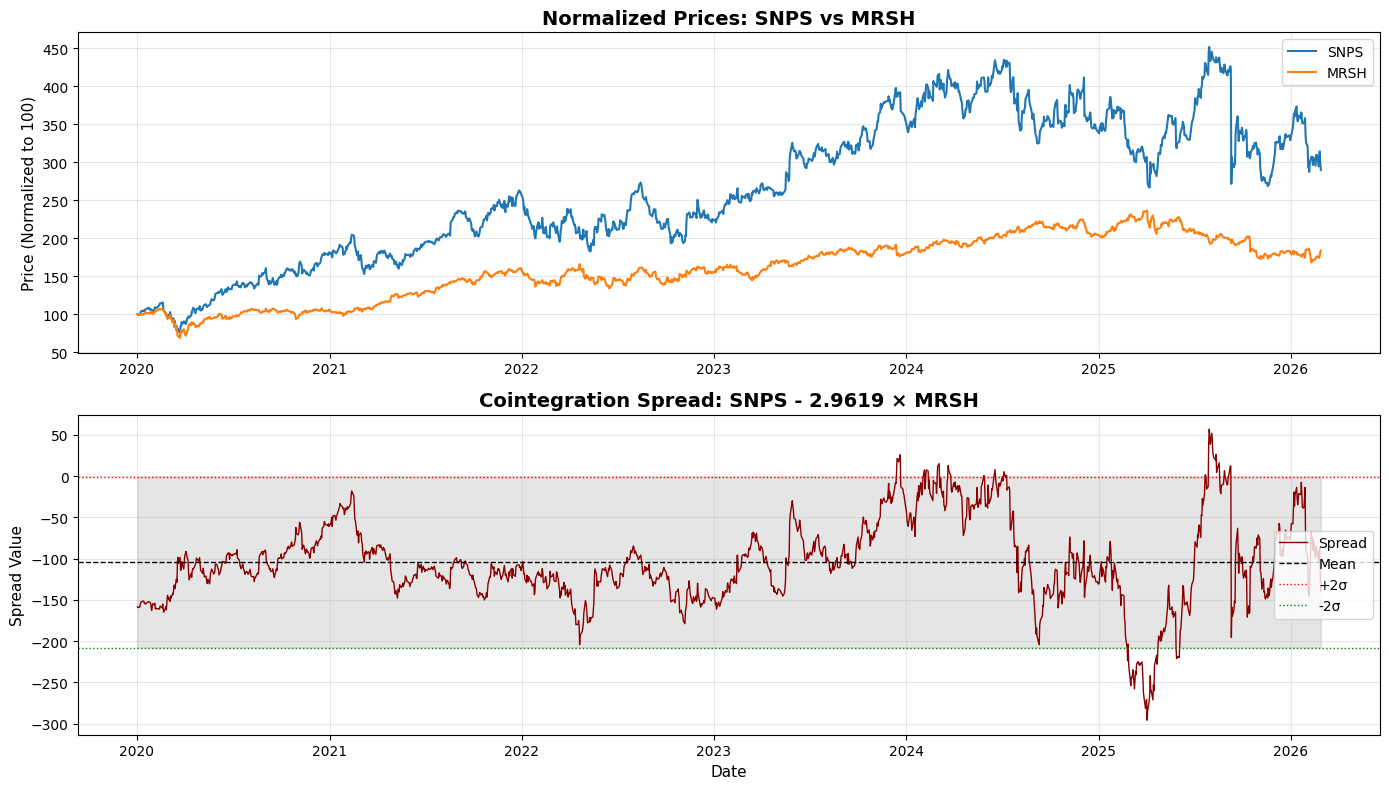


Spread Statistics for SNPS - MRSH:
Mean: -104.3582
Std Dev: 51.6921
Half-life (mean reversion): ~29.2 days

Pair #5: MA - ETN
ADF Statistic: -4.0784 (p-value: 0.0011)


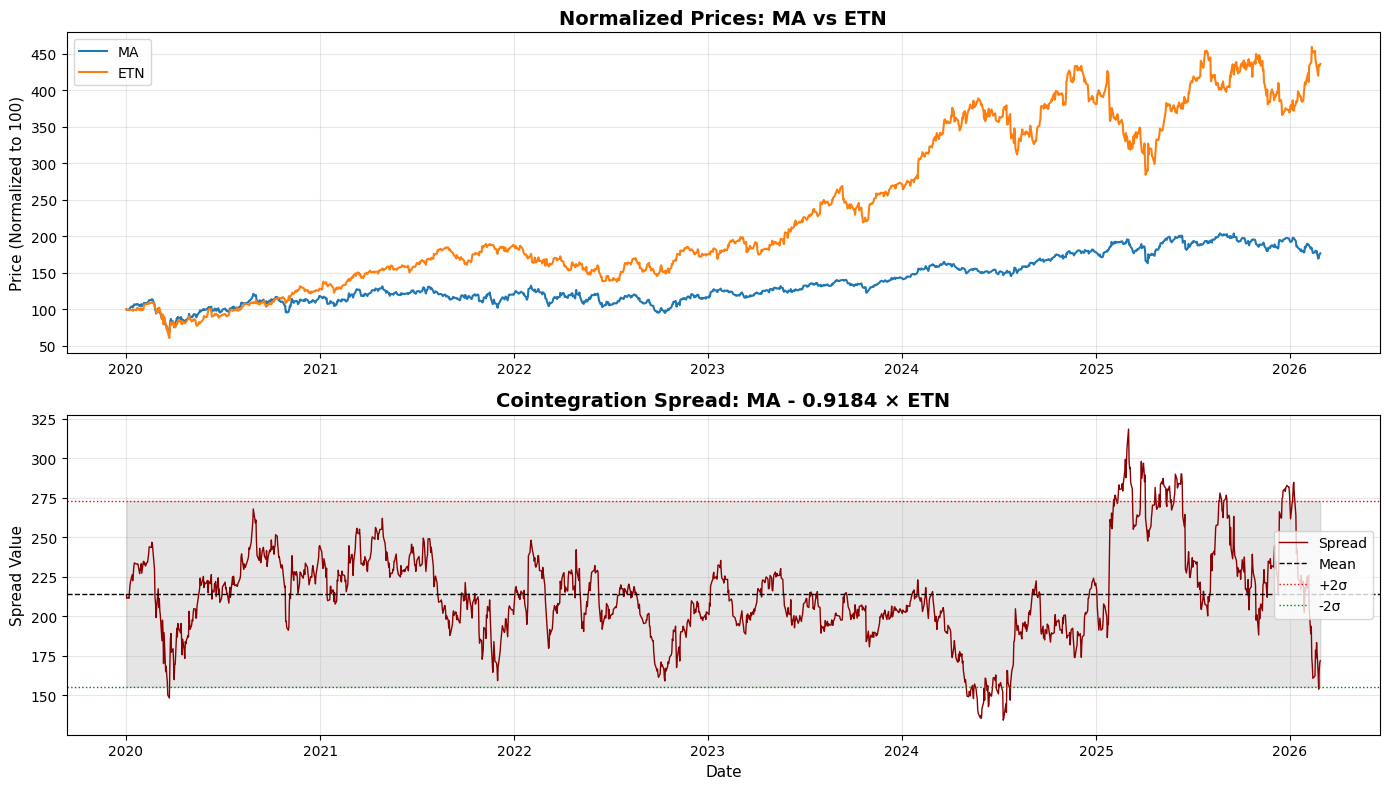


Spread Statistics for MA - ETN:
Mean: 214.2378
Std Dev: 29.3756
Half-life (mean reversion): ~29.3 days


In [12]:
# Optional: Visualize a cointegrated pair
import matplotlib.pyplot as plt

def plot_cointegrated_pair(prices: pd.DataFrame, ticker1: str, ticker2: str, beta: float):
    """
    Plots the normalized prices and spread for a cointegrated pair.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot 1: Normalized prices
    norm_price1 = prices[ticker1] / prices[ticker1].iloc[0] * 100
    norm_price2 = prices[ticker2] / prices[ticker2].iloc[0] * 100
    
    ax1.plot(norm_price1.index, norm_price1, label=ticker1, linewidth=1.5)
    ax1.plot(norm_price2.index, norm_price2, label=ticker2, linewidth=1.5)
    ax1.set_title(f'Normalized Prices: {ticker1} vs {ticker2}', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price (Normalized to 100)', fontsize=11)
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Spread (residuals)
    spread = prices[ticker1] - beta * prices[ticker2]
    mean_spread = spread.mean()
    std_spread = spread.std()
    
    ax2.plot(spread.index, spread, label='Spread', color='darkred', linewidth=1)
    ax2.axhline(mean_spread, color='black', linestyle='--', linewidth=1, label='Mean')
    ax2.axhline(mean_spread + 2*std_spread, color='red', linestyle=':', linewidth=1, label='+2σ')
    ax2.axhline(mean_spread - 2*std_spread, color='green', linestyle=':', linewidth=1, label='-2σ')
    ax2.fill_between(spread.index, mean_spread - 2*std_spread, mean_spread + 2*std_spread, 
                     alpha=0.2, color='gray')
    ax2.set_title(f'Cointegration Spread: {ticker1} - {beta:.4f} × {ticker2}', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Spread Value', fontsize=11)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\nSpread Statistics for {ticker1} - {ticker2}:")
    print(f"Mean: {mean_spread:.4f}")
    print(f"Std Dev: {std_spread:.4f}")
    # Half-life via OU approximation: Δspread_t = a + b * spread_{t-1} + ε_t
    spread_lag = spread.shift(1)
    spread_delta = spread - spread_lag
    hl_data = pd.concat([spread_lag, spread_delta], axis=1).dropna()
    hl_data.columns = ["lag", "delta"]

    if len(hl_data) > 2:
        b = LinearRegression().fit(hl_data[["lag"]], hl_data["delta"]).coef_[0]
        if b < 0:
            half_life = -np.log(2) / b
            print(f"Half-life (mean reversion): ~{half_life:.1f} days")
        else:
            print("Half-life: not defined (spread is not mean-reverting in this sample)")
    else:
        print("Half-life: not enough data")

# Plot the top 3 cointegrated pairs
for i in range(min(5, len(top_50_cointegrated))):
    row = top_50_cointegrated.iloc[i]
    print(f"\n{'='*60}")
    print(f"Pair #{i+1}: {row['ticker1']} - {row['ticker2']}")
    print(f"ADF Statistic: {row['adf_stat']:.4f} (p-value: {row['p_value']:.4f})")
    print(f"{'='*60}")
    plot_cointegrated_pair(prices, row['ticker1'], row['ticker2'], row['beta'])

In [15]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')
from io import StringIO
from pathlib import Path

# CSV_FILENAME = "sp500_data_2015-01-12_to_2026-01-02.csv"
# CSV_PATH = Path(__file__).resolve().parent / CSV_FILENAME

def load_tickers_from_file(file_path: str) -> list:
    """
    Loads tickers from a text file, one ticker per line.
    """
    with open(file_path, 'r') as f:
        tickers = [line.strip() for line in f if line.strip()]
    return tickers

def get_price_data(tickers: list, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Downloads adjusted close prices for given tickers.
    """
    print(f"Downloading price data for {len(tickers)} tickers...")
    
    raw = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=True,
        threads=True,
    )
    
    if raw.empty:
        raise ValueError("No data downloaded.")
    
    # Extract Adj Close prices
    if isinstance(raw.columns, pd.MultiIndex):
        if 'Adj Close' in raw.columns.get_level_values(0):
            prices = raw['Adj Close']
        else:
            raise ValueError("'Adj Close' not found in data.")
    else:
        prices = raw
    
    # Clean data: remove tickers with insufficient data
    min_observations = 100
    valid_tickers = [col for col in prices.columns if prices[col].notna().sum() > min_observations]
    prices = prices[valid_tickers].dropna(axis=1, how='all')
    
    print(f"Valid tickers after cleaning: {len(prices.columns)}")
    return prices

def test_cointegration(y: pd.Series, x: pd.Series) -> tuple:
    """
    Tests for cointegration between two price series using the Engle-Granger approach.
    
    Steps:
    1. Run OLS regression: y = α + β*x
    2. Calculate residuals (spread): ε = y - (α + β*x)
    3. Test residuals for stationarity using ADF test
    
    Returns:
    - adf_stat: ADF test statistic (more negative = stronger cointegration)
    - p_value: p-value of the ADF test
    - beta: hedge ratio from OLS regression
    """
    # Remove NaN values
    valid_idx = ~(y.isna() | x.isna())
    y_clean = y[valid_idx].values.reshape(-1, 1)
    x_clean = x[valid_idx].values.reshape(-1, 1)
    
    # Run OLS regression
    model = LinearRegression()
    model.fit(x_clean, y_clean)
    beta = model.coef_[0][0]
    
    # Calculate residuals (spread)
    spread = y_clean.flatten() - (model.predict(x_clean).flatten())
    
    # Run ADF test on the spread
    adf_result = adfuller(spread, maxlag=1, regression='c', autolag=None)
    adf_stat = adf_result[0]
    p_value = adf_result[1]
    
    return adf_stat, p_value, beta

# Load tickers from file
ticker_file = r"G:\Mi unidad\2026\Tesis\Códigos\Data\tickers\sp500_tickers_All.txt"
tickers = load_tickers_from_file(ticker_file)
print(f"Loaded {len(tickers)} tickers from file")

#Tickers MI Log Price
tickers_pairs = [
    ('RSG', 'WM'), ('MA', 'V'), ('CDNS', 'SNPS'), ('AJG', 'BRO'), ('AJG', 'MRSH'),
    ('AJG', 'RSG'), ('MCO', 'SPGI'), ('AJG', 'CTAS'), ('MSFT', 'NVDA'), ('CTAS', 'RSG'),
    ('BRO', 'MRSH'), ('AJG', 'PGR'), ('AJG', 'AON'), ('CTAS', 'MSI'), ('BRO', 'RSG'),
    ('BRO', 'CTAS'), ('KLAC', 'LRCX'), ('AJG', 'MSI'), ('CDNS', 'MSFT'), ('MSI', 'RSG'),
    ('AMAT', 'LRCX'), ('AJG', 'WM'), ('CTAS', 'PGR'), ('CPRT', 'CTAS'), ('CTAS', 'MSFT'),
    ('AJG', 'MSFT'), ('CTAS', 'FICO'), ('CTAS', 'WM'), ('MSFT', 'SNPS'), ('AVGO', 'NVDA'),
    ('CPRT', 'MSFT'), ('MSI', 'WM'), ('CTAS', 'MRSH'), ('MRSH', 'RSG'), ('AJG', 'TT'),
    ('INTU', 'MSFT'), ('PGR', 'RSG'), ('AZO', 'ORLY'), ('AJG', 'FICO'), ('AJG', 'CPRT'),
    ('CTAS', 'SNPS'), ('GOOG', 'MSFT'), ('MSFT', 'RSG'), ('AMAT', 'KLAC'), ('MSFT', 'MSI'),
    ('BRO', 'MSFT'), ('CDNS', 'CTAS'), ('AVGO', 'KLAC'), ('AON', 'MRSH'), ('ETN', 'PH')
]

# Download only tickers used in the selected pairs
tickers = sorted({t for p in tickers_pairs for t in p})
print(f"Using {len(tickers)} unique tickers from {len(tickers_pairs)} selected pairs")

def find_cointegrated_pairs(prices: pd.DataFrame, max_pairs: int = 50) -> pd.DataFrame:
    """
    Test only the pairs listed in tickers_pairs.
    """
    unique_pairs = list(dict.fromkeys(tickers_pairs))  # remove duplicate tuples, keep order
    print(f"\nTesting {len(unique_pairs)} selected pairs for cointegration...\n")

    results = []
    for i, (ticker1, ticker2) in enumerate(unique_pairs):
        if (i + 1) % 10 == 0:
            print(f"Progress: {i+1}/{len(unique_pairs)} pairs tested")

        if ticker1 not in prices.columns or ticker2 not in prices.columns:
            continue

        try:
            adf1, pval1, beta1 = test_cointegration(prices[ticker1], prices[ticker2])
            adf2, pval2, beta2 = test_cointegration(prices[ticker2], prices[ticker1])

            if adf1 < adf2:
                results.append({'ticker1': ticker1, 'ticker2': ticker2, 'adf_stat': adf1, 'p_value': pval1, 'beta': beta1})
            else:
                results.append({'ticker1': ticker2, 'ticker2': ticker1, 'adf_stat': adf2, 'p_value': pval2, 'beta': beta2})
        except Exception:
            continue

    results_df = pd.DataFrame(results).sort_values('adf_stat', ascending=True).reset_index(drop=True)
    return results_df.head(min(max_pairs, len(results_df)))
# Download price data (use prices, not returns, for cointegration testing)
# downloaded_data = load_data_as_downloaded(CSV_PATH)
# prices = downloaded_data.xs('Close', axis=1, level=0)
prices = get_price_data(tickers, start_date='2024-01-01', end_date='2026-03-01')

# Find top 50 cointegrated pairs
top_50_cointegrated = find_cointegrated_pairs(prices, max_pairs=50)

# Display results
print("\n" + "="*80)
print("TOP 50 MOST COINTEGRATED PAIRS (Engle-Granger ADF Test)")
print("="*80)
print(f"{'Rank':<6}{'Ticker 1':<10}{'Ticker 2':<10}{'ADF Stat':<12}{'P-Value':<12}{'Beta':<10}")
print("-"*80)

for idx, row in top_50_cointegrated.iterrows():
    sig = "***" if row['p_value'] < 0.01 else ("**" if row['p_value'] < 0.05 else ("*" if row['p_value'] < 0.10 else ""))
    print(f"{idx+1:<6}{row['ticker1']:<10}{row['ticker2']:<10}{row['adf_stat']:<12.4f}{row['p_value']:<12.4f}{row['beta']:<10.4f} {sig}")

print("\n*** p < 0.01, ** p < 0.05, * p < 0.10")
print("\nNote: More negative ADF statistic indicates stronger cointegration")
print("Critical values: 1%: -3.43, 5%: -2.86, 10%: -2.57")

# Save results to CSV
output_file = r"G:\Mi unidad\2026\Tesis\Códigos\Data\top_50_cointegrated_pairs.csv"
top_50_cointegrated.to_csv(output_file, index=False)
print(f"\nResults saved to: {output_file}")

Loaded 500 tickers from file
Using 30 unique tickers from 50 selected pairs


[*********************100%***********************]  30 of 30 completed


Valid tickers after cleaning: 30

Testing 50 selected pairs for cointegration...

Progress: 10/50 pairs tested
Progress: 20/50 pairs tested
Progress: 30/50 pairs tested
Progress: 40/50 pairs tested
Progress: 50/50 pairs tested

TOP 50 MOST COINTEGRATED PAIRS (Engle-Granger ADF Test)
Rank  Ticker 1  Ticker 2  ADF Stat    P-Value     Beta      
--------------------------------------------------------------------------------
1     CDNS      MSFT      -3.8829     0.0022      0.5330     ***
2     MRSH      BRO       -3.6357     0.0051      1.0791     ***
3     NVDA      AVGO      -3.5656     0.0065      0.4210     ***
4     AZO       ORLY      -3.2683     0.0164      34.0570    **
5     WM        RSG       -3.0853     0.0277      0.5508     **
6     KLAC      LRCX      -2.9684     0.0379      5.4859     **
7     PGR       AJG       -2.8241     0.0549      0.7404     *
8     SNPS      CTAS      -2.8136     0.0564      -0.4019    *
9     MA        V         -2.7987     0.0585      1.3783     


Pair #1: CDNS - MSFT
ADF Statistic: -3.8829 (p-value: 0.0022)


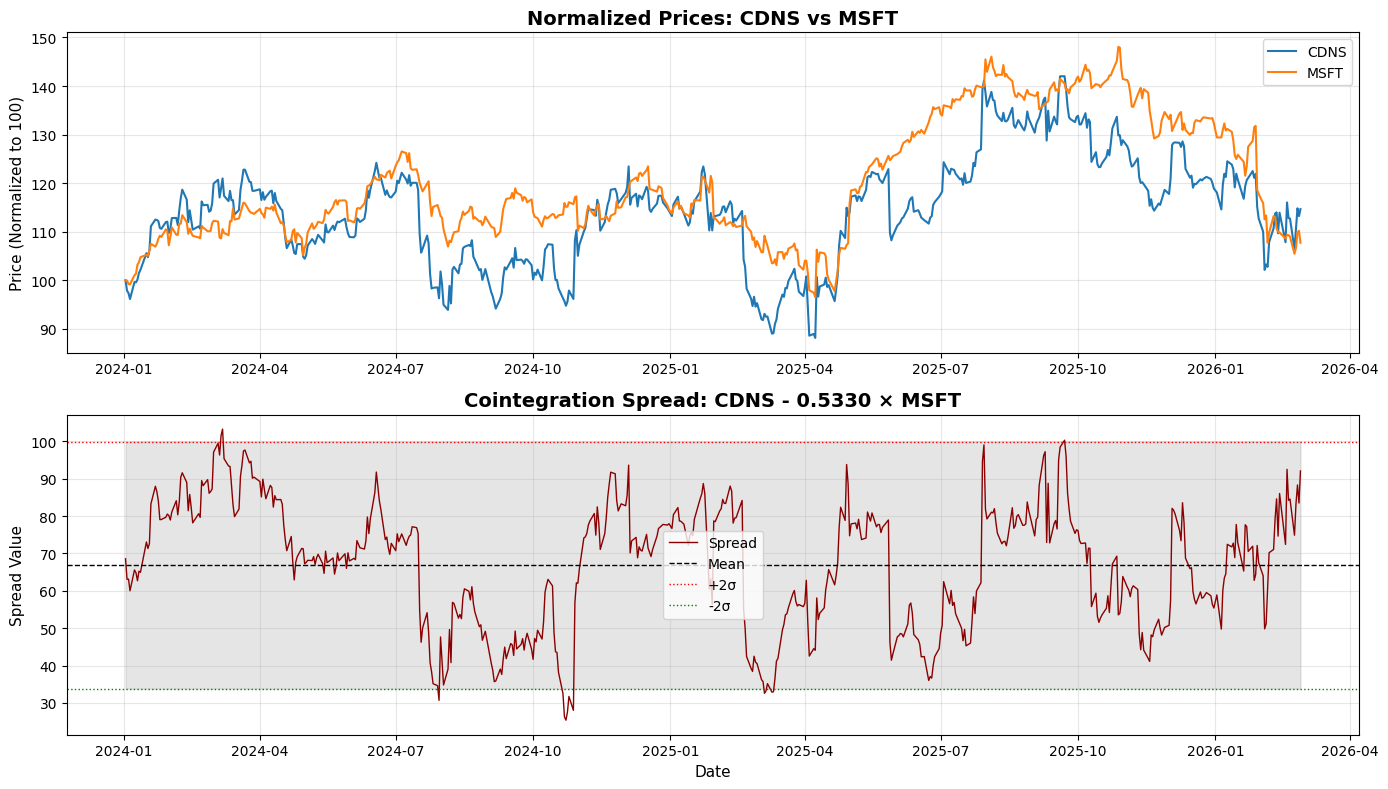


Spread Statistics for CDNS - MSFT:
Mean: 66.8654
Std Dev: 16.5285
Half-life (mean reversion): ~10.7 days

Pair #2: MRSH - BRO
ADF Statistic: -3.6357 (p-value: 0.0051)


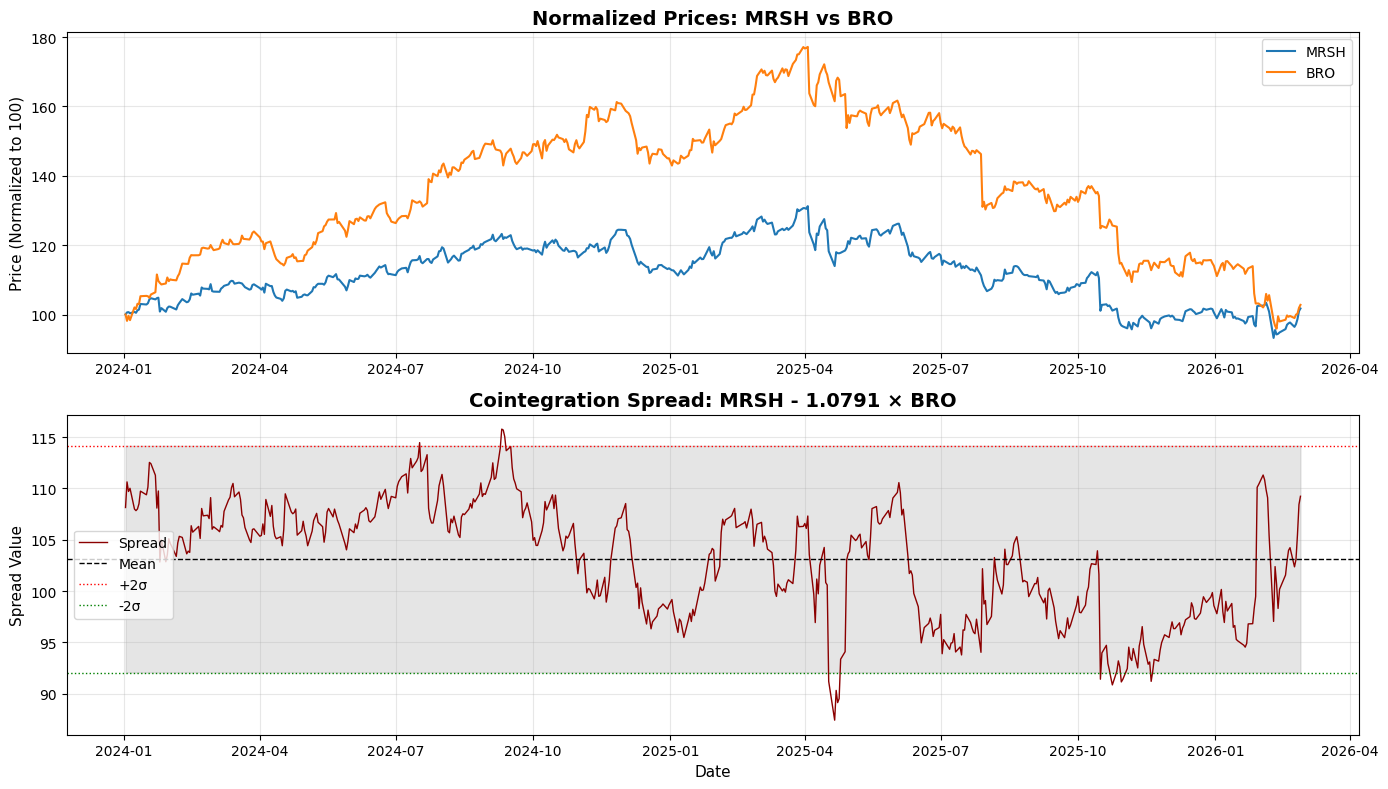


Spread Statistics for MRSH - BRO:
Mean: 103.1121
Std Dev: 5.5289
Half-life (mean reversion): ~14.0 days

Pair #3: NVDA - AVGO
ADF Statistic: -3.5656 (p-value: 0.0065)


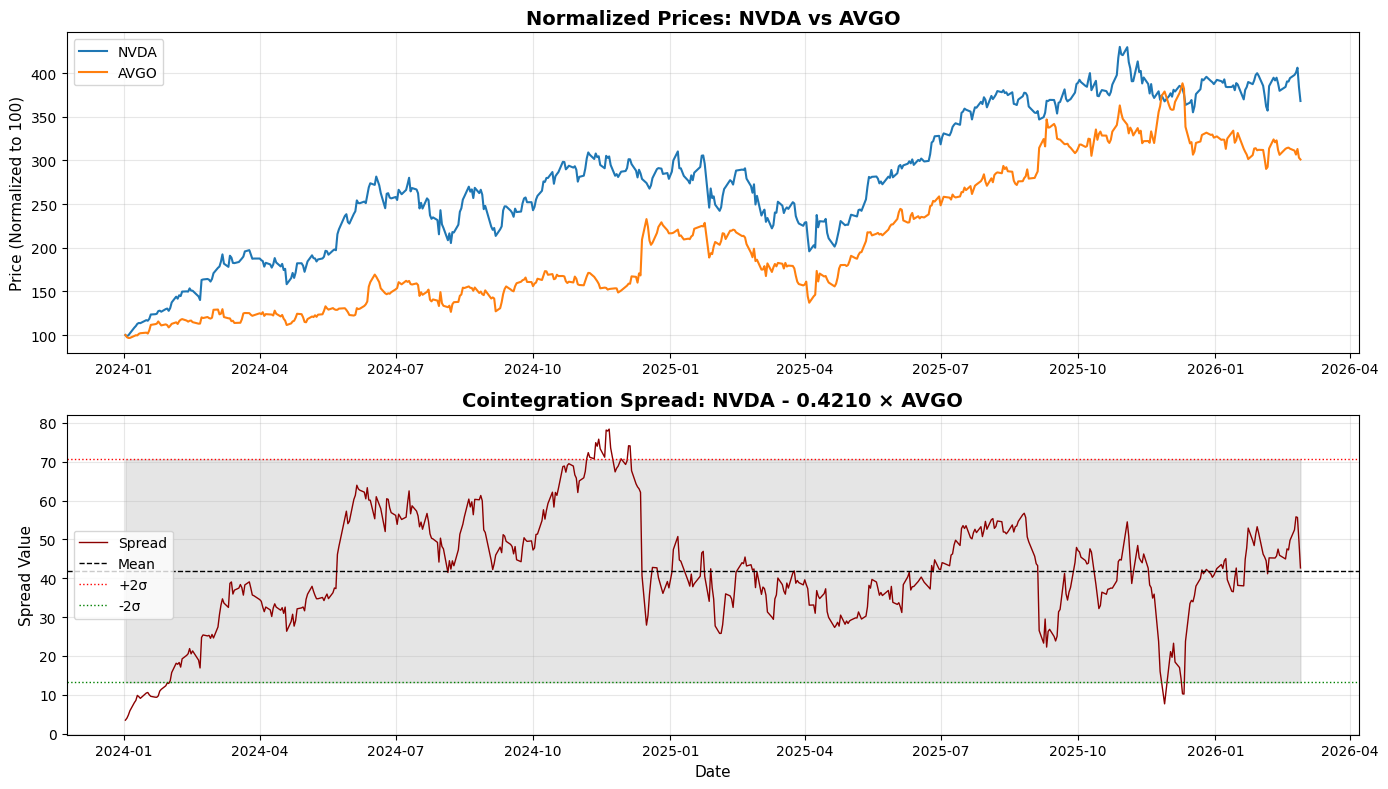


Spread Statistics for NVDA - AVGO:
Mean: 41.9119
Std Dev: 14.3573
Half-life (mean reversion): ~21.5 days

Pair #4: AZO - ORLY
ADF Statistic: -3.2683 (p-value: 0.0164)


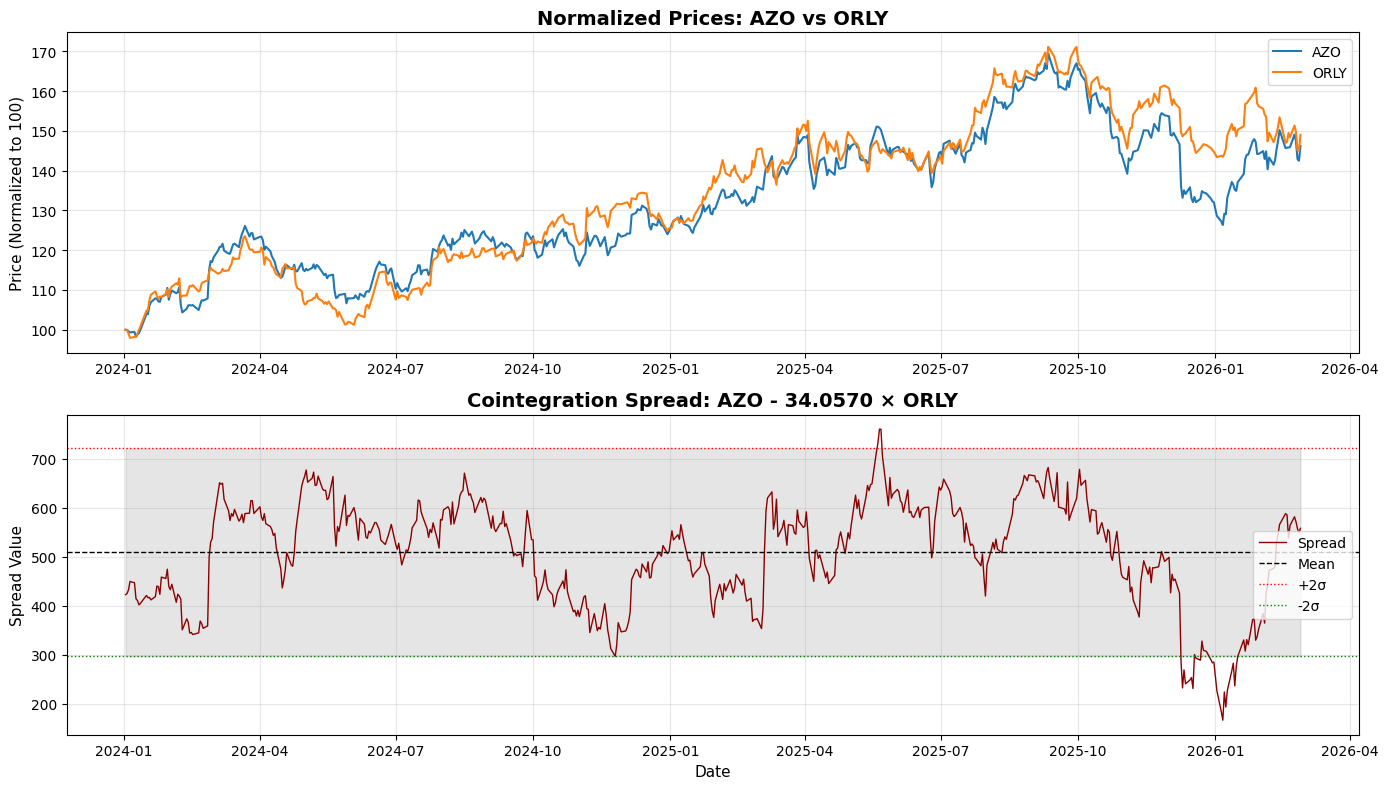


Spread Statistics for AZO - ORLY:
Mean: 509.4251
Std Dev: 106.2649
Half-life (mean reversion): ~17.4 days

Pair #5: WM - RSG
ADF Statistic: -3.0853 (p-value: 0.0277)


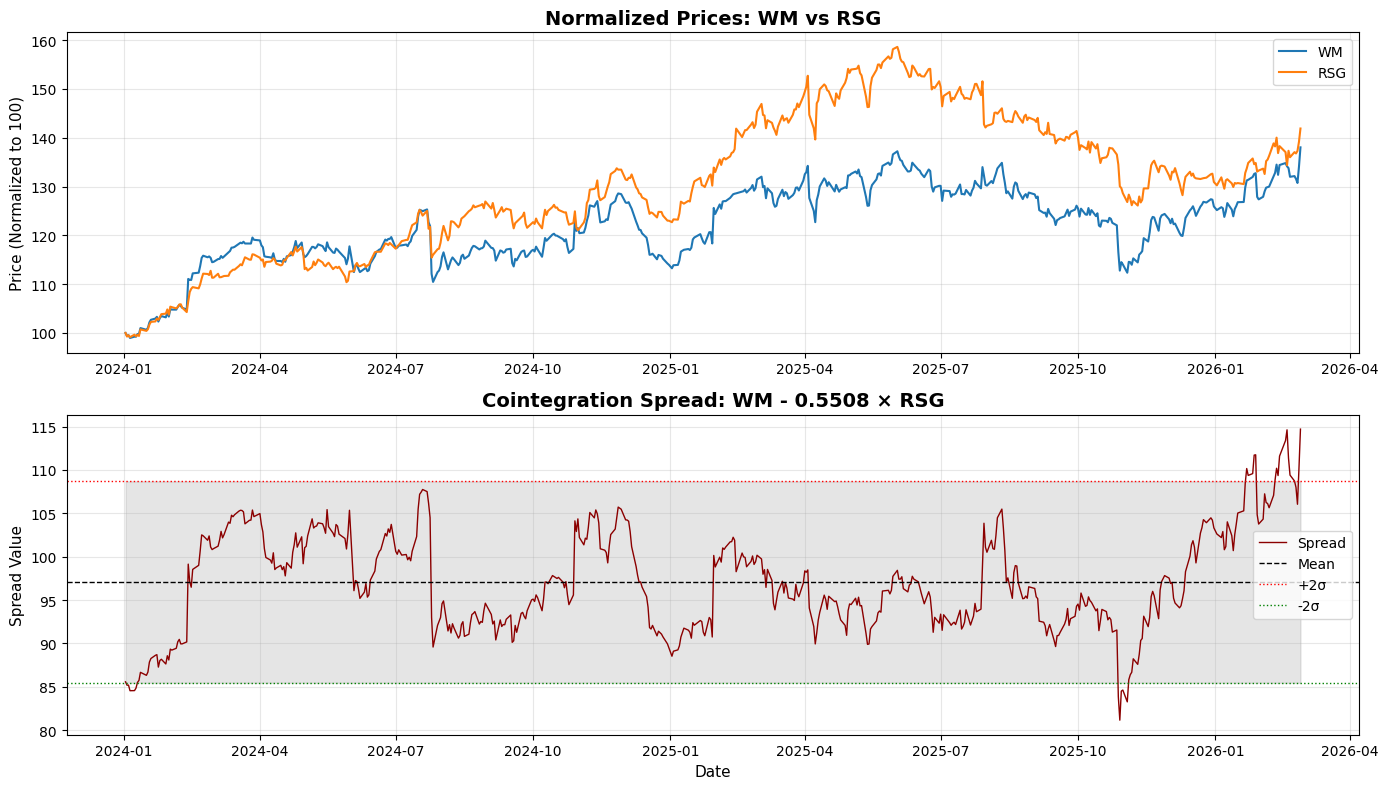


Spread Statistics for WM - RSG:
Mean: 97.0768
Std Dev: 5.8050
Half-life (mean reversion): ~18.8 days


In [16]:
# Optional: Visualize a cointegrated pair
import matplotlib.pyplot as plt

def plot_cointegrated_pair(prices: pd.DataFrame, ticker1: str, ticker2: str, beta: float):
    """
    Plots the normalized prices and spread for a cointegrated pair.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot 1: Normalized prices
    norm_price1 = prices[ticker1] / prices[ticker1].iloc[0] * 100
    norm_price2 = prices[ticker2] / prices[ticker2].iloc[0] * 100
    
    ax1.plot(norm_price1.index, norm_price1, label=ticker1, linewidth=1.5)
    ax1.plot(norm_price2.index, norm_price2, label=ticker2, linewidth=1.5)
    ax1.set_title(f'Normalized Prices: {ticker1} vs {ticker2}', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price (Normalized to 100)', fontsize=11)
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Spread (residuals)
    spread = prices[ticker1] - beta * prices[ticker2]
    mean_spread = spread.mean()
    std_spread = spread.std()
    
    ax2.plot(spread.index, spread, label='Spread', color='darkred', linewidth=1)
    ax2.axhline(mean_spread, color='black', linestyle='--', linewidth=1, label='Mean')
    ax2.axhline(mean_spread + 2*std_spread, color='red', linestyle=':', linewidth=1, label='+2σ')
    ax2.axhline(mean_spread - 2*std_spread, color='green', linestyle=':', linewidth=1, label='-2σ')
    ax2.fill_between(spread.index, mean_spread - 2*std_spread, mean_spread + 2*std_spread, 
                     alpha=0.2, color='gray')
    ax2.set_title(f'Cointegration Spread: {ticker1} - {beta:.4f} × {ticker2}', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Spread Value', fontsize=11)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\nSpread Statistics for {ticker1} - {ticker2}:")
    print(f"Mean: {mean_spread:.4f}")
    print(f"Std Dev: {std_spread:.4f}")
    # Half-life via OU approximation: Δspread_t = a + b * spread_{t-1} + ε_t
    spread_lag = spread.shift(1)
    spread_delta = spread - spread_lag
    hl_data = pd.concat([spread_lag, spread_delta], axis=1).dropna()
    hl_data.columns = ["lag", "delta"]

    if len(hl_data) > 2:
        b = LinearRegression().fit(hl_data[["lag"]], hl_data["delta"]).coef_[0]
        if b < 0:
            half_life = -np.log(2) / b
            print(f"Half-life (mean reversion): ~{half_life:.1f} days")
        else:
            print("Half-life: not defined (spread is not mean-reverting in this sample)")
    else:
        print("Half-life: not enough data")

# Plot the top 3 cointegrated pairs
for i in range(min(5, len(top_50_cointegrated))):
    row = top_50_cointegrated.iloc[i]
    print(f"\n{'='*60}")
    print(f"Pair #{i+1}: {row['ticker1']} - {row['ticker2']}")
    print(f"ADF Statistic: {row['adf_stat']:.4f} (p-value: {row['p_value']:.4f})")
    print(f"{'='*60}")
    plot_cointegrated_pair(prices, row['ticker1'], row['ticker2'], row['beta'])